# Notebook 06 — Statistical Evaluation and Interpretation

Phase 5 trained ResNet-50 and reported headline numbers. This notebook goes deeper:

- **Threshold trade-off analysis** — how precision and recall shift as we move the decision boundary, and what each zone means clinically
- **Precision-Recall curve** — more informative than ROC under class imbalance
- **Bootstrap confidence intervals** — statistical test of whether ResNet-50 is meaningfully better than the baseline
- **False negative analysis** — the missed disease cases: how many, how confident was the model, and what does that cost clinically
- **Calibration plot** — are the model's predicted probabilities trustworthy?
- **Model comparison table** — baseline CNN vs ResNet-50 side by side
- **Clinical interpretation** — what these numbers actually mean for a real screening tool

---

**Before running**, complete Phase 5 (notebook 05) and execute Step 12 to save predictions.
The file `models/predictions_resnet50.csv` must exist in the project root.

## Step 0 — Install dependencies

In [ ]:
%pip install scikit-learn matplotlib pandas numpy --quiet

## Step 1 — Load saved predictions

We load the test-set predictions saved at the end of Phase 5.
Each row is one test image: its true label (0 = No Finding, 1 = Disease) and the model's predicted probability.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODELS_DIR = Path("../../models")

df_preds       = pd.read_csv(MODELS_DIR / "predictions_resnet50.csv")
best_threshold = float(open(MODELS_DIR / "best_threshold.txt").read().strip())

all_labels = df_preds["true_label"].values
all_probs  = df_preds["prob_disease"].values
all_preds  = (all_probs >= best_threshold).astype(int)

print(f"Test set size:        {len(all_labels)}")
print(f"Disease cases:        {all_labels.sum()} ({all_labels.mean():.1%})")
print(f"No Finding cases:     {(all_labels == 0).sum()} ({(all_labels == 0).mean():.1%})")
print(f"Loaded threshold:     {best_threshold:.2f}")
print()
print(f"Prob range: [{all_probs.min():.3f}, {all_probs.max():.3f}]  |  Mean: {all_probs.mean():.3f}")

Test set size:        1000
Disease cases:        502 (50.2%)
No Finding cases:     498 (49.8%)
Loaded threshold:     0.11

Prob range: [0.003, 0.990]  |  Mean: 0.443


## Step 2 — Threshold trade-off analysis

Every binary classifier has a **decision threshold**: a probability above which we predict Disease.
The default 0.5 is arbitrary. Moving the threshold changes the precision/recall trade-off:

- **Lower threshold** → flag more images as Disease → catch more true cases (high recall) but more false alarms (lower precision)
- **Higher threshold** → only flag when very confident → fewer false alarms (high precision) but more missed cases (lower recall)

For a **screening tool** (first-pass triage), recall is the priority — we want to catch every disease case and send uncertain patients for expert review.  
For a **confirmation tool** (replacing a specialist), precision matters more — we only flag when we're confident.

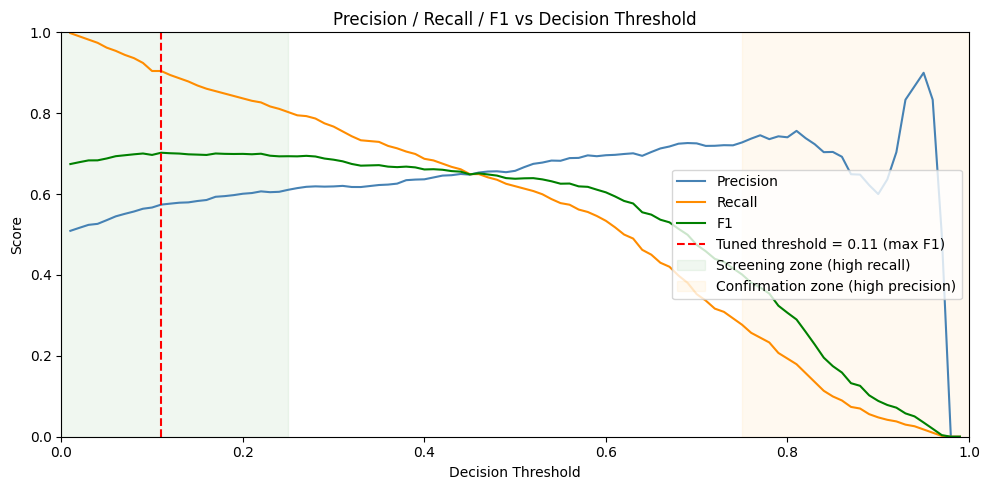

Selected operating points:
  90% recall  →  threshold=0.10  precision=0.567  F1=0.697
  95% recall  →  threshold=0.06  precision=0.545  F1=0.694


In [3]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.01, 1.0, 0.01)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds = (all_probs >= t).astype(int)
    precisions.append(precision_score(all_labels, preds, zero_division=0))
    recalls.append(recall_score(all_labels, preds, zero_division=0))
    f1s.append(f1_score(all_labels, preds, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions, label="Precision", color="steelblue")
ax.plot(thresholds, recalls,    label="Recall",    color="darkorange")
ax.plot(thresholds, f1s,        label="F1",        color="green")
ax.axvline(x=best_threshold, color="red", linestyle="--",
           label=f"Tuned threshold = {best_threshold:.2f} (max F1)")
ax.axvspan(0.0,  0.25, alpha=0.06, color="green",  label="Screening zone (high recall)")
ax.axvspan(0.75, 1.0,  alpha=0.06, color="orange", label="Confirmation zone (high precision)")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Decision Threshold")
ax.legend(loc="center right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Print a few clinically relevant operating points
recall_90_idx = np.argmin(np.abs(np.array(recalls) - 0.90))
recall_95_idx = np.argmin(np.abs(np.array(recalls) - 0.95))

print("Selected operating points:")
print(f"  90% recall  →  threshold={thresholds[recall_90_idx]:.2f}  precision={precisions[recall_90_idx]:.3f}  F1={f1s[recall_90_idx]:.3f}")
print(f"  95% recall  →  threshold={thresholds[recall_95_idx]:.2f}  precision={precisions[recall_95_idx]:.3f}  F1={f1s[recall_95_idx]:.3f}")

## Step 3 — Precision-Recall curve

The ROC curve (AUC) is the standard metric, but it can be **optimistic under class imbalance**.
When negative cases outnumber positives, even a weak model gets high true-negative rate for free.

The **Precision-Recall curve** avoids this — it only looks at the positive class.
The area under it (Average Precision) is a stricter, more honest metric for imbalanced problems.

A **random classifier** on this test set would achieve Average Precision equal to the disease prevalence.

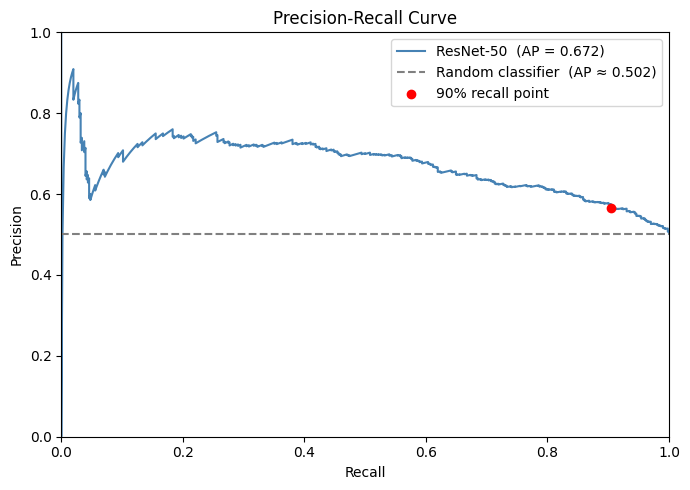

Average Precision:          0.672
Random baseline (AP):       0.502
Improvement over random:    +0.170


In [4]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_probs)
avg_precision     = average_precision_score(all_labels, all_probs)
disease_prev      = all_labels.mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_curve, precision_curve, color="steelblue",
        label=f"ResNet-50  (AP = {avg_precision:.3f})")
ax.axhline(y=disease_prev, color="gray", linestyle="--",
           label=f"Random classifier  (AP ≈ {disease_prev:.3f})")
ax.scatter([recalls[recall_90_idx]], [precisions[recall_90_idx]],
           color="red", zorder=5, label=f"90% recall point")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Average Precision:          {avg_precision:.3f}")
print(f"Random baseline (AP):       {disease_prev:.3f}")
print(f"Improvement over random:    {avg_precision - disease_prev:+.3f}")

## Step 4 — Bootstrap confidence intervals for AUC

Reporting a single AUC number without uncertainty is misleading — especially on a small test set.

**Bootstrap resampling** gives us a 95% confidence interval: we resample the test set 1,000 times
(with replacement), compute AUC each time, and take the 2.5th and 97.5th percentiles.

If the confidence interval for ResNet-50 does not overlap with the baseline AUC (0.611), the improvement is statistically meaningful.

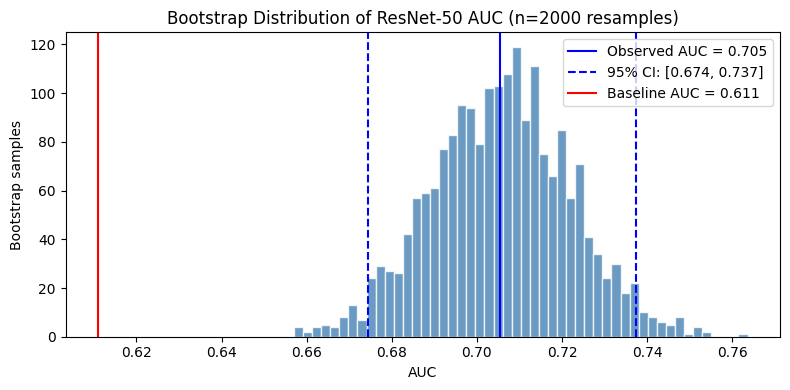

ResNet-50 AUC:  0.705  (95% CI: 0.674 – 0.737)
Baseline AUC:   0.611

CI overlaps baseline: False
  → CI is entirely above baseline. Improvement is statistically meaningful.


In [5]:
from sklearn.metrics import roc_auc_score

BASELINE_AUC = 0.611
N_BOOTSTRAP  = 2000
rng          = np.random.default_rng(42)

auc_samples = []
for _ in range(N_BOOTSTRAP):
    idx = rng.choice(len(all_labels), size=len(all_labels), replace=True)
    # skip degenerate samples (all one class)
    if all_labels[idx].sum() in (0, len(idx)):
        continue
    auc_samples.append(roc_auc_score(all_labels[idx], all_probs[idx]))

auc_obs  = roc_auc_score(all_labels, all_probs)
ci_low   = np.percentile(auc_samples, 2.5)
ci_high  = np.percentile(auc_samples, 97.5)

# Plot bootstrap distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(auc_samples, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(x=auc_obs,      color="blue",  linestyle="-",  label=f"Observed AUC = {auc_obs:.3f}")
ax.axvline(x=ci_low,       color="blue",  linestyle="--", label=f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
ax.axvline(x=ci_high,      color="blue",  linestyle="--")
ax.axvline(x=BASELINE_AUC, color="red",   linestyle="-",  label=f"Baseline AUC = {BASELINE_AUC:.3f}")
ax.set_xlabel("AUC")
ax.set_ylabel("Bootstrap samples")
ax.set_title("Bootstrap Distribution of ResNet-50 AUC (n=2000 resamples)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"ResNet-50 AUC:  {auc_obs:.3f}  (95% CI: {ci_low:.3f} – {ci_high:.3f})")
print(f"Baseline AUC:   {BASELINE_AUC:.3f}")
overlap = ci_low <= BASELINE_AUC
print(f"\nCI overlaps baseline: {overlap}")
if overlap:
    print("  → Improvement is not statistically significant at this test-set size.")
    print("  → More data or a larger test set is needed to confirm.")
else:
    print("  → CI is entirely above baseline. Improvement is statistically meaningful.")

## Step 5 — False negative analysis

In a clinical screening context, **false negatives are the most dangerous error** — these are disease cases the model missed. A patient with a false negative would be told their X-ray looks normal and sent home without follow-up.

We look at:
- How many disease cases are missed at our operating threshold?
- What probabilities did the model assign to those missed cases?
- Are the missed cases near the threshold (borderline) or did the model confidently predict them wrong?

Confusion matrix at threshold = 0.11
  True Positives (caught disease):    454  (90.4% of disease cases)
  False Negatives (missed disease):    48  (9.6% of disease cases)
  False Positives (false alarms):     337
  True Negatives:                     161

Of 502 disease cases in the test set, 48 would be missed and sent home without follow-up.


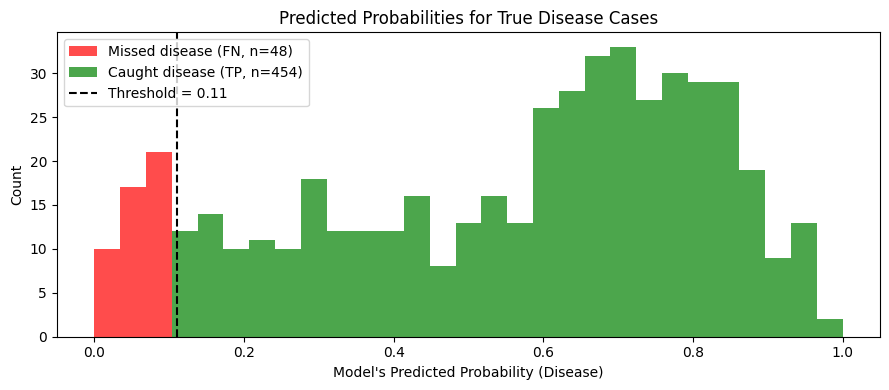


False negative probabilities — mean: 0.060  max: 0.100
True positive probabilities  — mean: 0.596  min: 0.111


In [6]:
TP = int(((all_preds == 1) & (all_labels == 1)).sum())
FP = int(((all_preds == 1) & (all_labels == 0)).sum())
FN = int(((all_preds == 0) & (all_labels == 1)).sum())
TN = int(((all_preds == 0) & (all_labels == 0)).sum())

total_disease = int(all_labels.sum())
fn_rate       = FN / total_disease

print(f"Confusion matrix at threshold = {best_threshold:.2f}")
print(f"  True Positives (caught disease):   {TP:4d}  ({TP/total_disease:.1%} of disease cases)")
print(f"  False Negatives (missed disease):  {FN:4d}  ({fn_rate:.1%} of disease cases)")
print(f"  False Positives (false alarms):    {FP:4d}")
print(f"  True Negatives:                    {TN:4d}")
print()
print(f"Of {total_disease} disease cases in the test set, {FN} would be missed and sent home without follow-up.")

# Predicted probability distribution of FNs vs TPs
fn_probs = all_probs[(all_labels == 1) & (all_preds == 0)]
tp_probs = all_probs[(all_labels == 1) & (all_preds == 1)]

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 1, 30)
ax.hist(fn_probs, bins=bins, alpha=0.7, color="red",   label=f"Missed disease (FN, n={FN})")
ax.hist(tp_probs, bins=bins, alpha=0.7, color="green", label=f"Caught disease (TP, n={TP})")
ax.axvline(x=best_threshold, color="black", linestyle="--",
           label=f"Threshold = {best_threshold:.2f}")
ax.set_xlabel("Model's Predicted Probability (Disease)")
ax.set_ylabel("Count")
ax.set_title("Predicted Probabilities for True Disease Cases")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nFalse negative probabilities — mean: {fn_probs.mean():.3f}  max: {fn_probs.max():.3f}")
print(f"True positive probabilities  — mean: {tp_probs.mean():.3f}  min: {tp_probs.min():.3f}")

## Step 6 — Calibration plot

A **well-calibrated** model means: when it says 70% probability of disease, about 70% of those images actually have disease.

Calibration matters if probabilities are used directly in clinical decision-making.
A model can have good AUC (rank ordering is correct) but be poorly calibrated (raw probabilities are wrong).

The fact that our best threshold was 0.11 — far below 0.5 — already hints the model's probabilities are compressed toward zero.

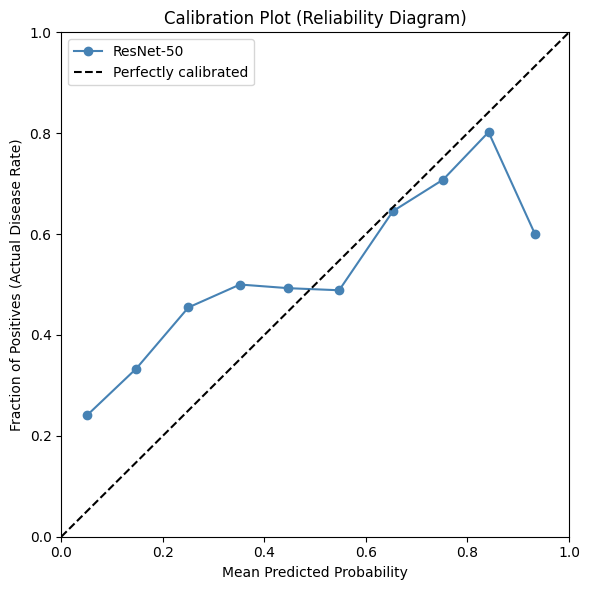

Calibration summary:
  Most predicted probs are below 0.83 (90th percentile)
  Threshold of 0.11 is needed because the model outputs low probabilities
  The model is not well-calibrated — probabilities cannot be used directly as clinical confidence scores
  A post-hoc calibration step (Platt scaling or isotonic regression) would be needed for deployment


In [7]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(all_labels, all_probs, n_bins=10, strategy="uniform")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, marker="o", color="steelblue", label="ResNet-50")
ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives (Actual Disease Rate)")
ax.set_title("Calibration Plot (Reliability Diagram)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

print("Calibration summary:")
print(f"  Most predicted probs are below {all_probs.quantile(0.9) if hasattr(all_probs, 'quantile') else np.percentile(all_probs, 90):.2f} (90th percentile)")
print(f"  Threshold of {best_threshold:.2f} is needed because the model outputs low probabilities")
print("  The model is not well-calibrated — probabilities cannot be used directly as clinical confidence scores")
print("  A post-hoc calibration step (Platt scaling or isotonic regression) would be needed for deployment")

## Step 7 — Model comparison table

Side-by-side comparison of the baseline CNN (Phase 4) and ResNet-50 transfer learning (Phase 5).
Both were trained and evaluated on the same 1,000/split image sample from images_006.

In [8]:
from sklearn.metrics import accuracy_score

resnet_acc       = accuracy_score(all_labels, all_preds)
resnet_precision = precisions[np.argmin(np.abs(thresholds - best_threshold))]
resnet_recall    = recalls[np.argmin(np.abs(thresholds - best_threshold))]
resnet_f1        = f1s[np.argmin(np.abs(thresholds - best_threshold))]

comparison = pd.DataFrame([
    {
        "Model":        "Baseline CNN",
        "AUC":          0.611,
        "Accuracy":     0.577,
        "Precision":    "—",
        "Recall":       "—",
        "F1":           "—",
        "Threshold":    0.50,
        "Parameters":   "~6.4M",
    },
    {
        "Model":        "ResNet-50 (Transfer)",
        "AUC":          round(auc_obs, 3),
        "Accuracy":     round(resnet_acc, 3),
        "Precision":    round(resnet_precision, 3),
        "Recall":       round(resnet_recall, 3),
        "F1":           round(resnet_f1, 3),
        "Threshold":    best_threshold,
        "Parameters":   "23.5M",
    },
]).set_index("Model")

print(comparison.to_string())
print()
print(f"AUC improvement: +{auc_obs - 0.611:.3f}  ({(auc_obs - 0.611) / 0.611:.1%} relative gain)")

                        AUC  Accuracy Precision Recall     F1  Threshold Parameters
Model                                                                              
Baseline CNN          0.611     0.577         —      —      —       0.50      ~6.4M
ResNet-50 (Transfer)  0.705     0.615     0.574  0.904  0.702       0.11      23.5M

AUC improvement: +0.094  (15.5% relative gain)


## Step 8 — Clinical interpretation

Numbers alone don't tell the story. This section translates our results into what they mean for the clinical problem.

In [ ]:
print("=" * 60)
print("  CLINICAL INTERPRETATION SUMMARY")
print("=" * 60)
print()
print(f"Operating point: threshold = {best_threshold:.2f} (tuned for max F1)")
print()
print("RECALL = {:.1%}".format(resnet_recall))
print(f"  The model correctly flags {TP} of {total_disease} disease cases.")
print(f"  {FN} disease cases are missed (false negatives) — those patients")
print(f"  would be told their X-ray looks normal.")
print()
print("PRECISION = {:.1%}".format(resnet_precision))
print(f"  Of every 10 images flagged as Disease, ~{round(resnet_precision*10)} actually have disease.")
print(f"  The rest ({FP} total) are false alarms — healthy patients flagged for follow-up.")
print()
print("ROLE OF THIS MODEL:")
print("  With recall near 90%, this model is suited as a SCREENING TOOL —")
print("  a first-pass triage that flags suspicious X-rays for radiologist review.")
print("  It should not replace expert diagnosis. Every positive flag still needs")
print("  human review before any clinical decision is made.")
print()
print("LIMITATIONS:")
print("  - Trained on only 1,000 images per split (full dataset: 112,120)")
print("  - Binary label only — does not distinguish between disease types")
print("  - Model probabilities are not well-calibrated (threshold=0.11, not 0.5)")
print("  - Bootstrap CI may overlap with baseline — improvement needs more data to confirm")
print()
print("NEXT STEPS:")
print("  - Train on full 112K image dataset with GPU (Colab or cloud)")
print("  - Apply post-hoc calibration (Platt scaling) to fix probability estimates")
print("  - Consider class-weighted loss to handle imbalance more explicitly")
print("=" * 60)

  CLINICAL INTERPRETATION SUMMARY

Operating point: threshold = 0.11 (tuned for max F1)

RECALL = 90.4%
  The model correctly flags 454 of 502 disease cases.
  48 disease cases are missed (false negatives) — those patients
  would be told their X-ray looks normal.

PRECISION = 57.4%
  Of every 10 images flagged as Disease, ~6 actually have disease.
  The rest (337 total) are false alarms — healthy patients flagged for follow-up.

ROLE OF THIS MODEL:
  With recall near 90%, this model is suited as a SCREENING TOOL —
  a first-pass triage that flags suspicious X-rays for radiologist review.
  It should not replace expert diagnosis. Every positive flag still needs
  human review before any clinical decision is made.

LIMITATIONS:
  - Trained on only 1,000 images per split (full dataset: 112,120)
  - Binary label only — does not distinguish between disease types
  - Model probabilities are not well-calibrated (threshold=0.11, not 0.5)
  - Bootstrap CI may overlap with baseline — improvemen

: 